In [2]:
import chipwhisperer as cw
scope = cw.scope()
scope.gain.db = 25
scope.adc.samples = 200
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = "tio4"
scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "disabled"

/home/mdphuc/chipwhisperer/software/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


In [3]:
import io

default_bsfile = "/home/mdphuc/chipwhisperer/hardware/victims/cw305_artixtarget/fpga/vivado_examples/aes128_verilog/aes128_verilog.runs/impl_100t/cw305_top.bit"
secworks_bsfile = "/home/mdphuc/UCDASEC/SCA/AES_Implementation/AESHardware/CW305_SecWorks/CW305_SecWorks_Vivado/CW305_SecWorks.runs/impl_1/cw305_top.bit"
ProjectVault_bsfile = "/home/mdphuc/UCDASEC/SCA/AES_Implementation/AESHardware/CW305_SecWorks/CW305_GoogleVault_Vivado/CW305_GoogleVault_Vivado/CW305_GoogleVault_Vivado.runs/impl_1/cw305_top.bit"
SMAesH_bsfile = "/home/mdphuc/UCDASEC/SCA/AES_Implementation/AESHardware/CW305_SMAesH/CW305_SMAesH_Vivado/CW305_SMAesH_Vivado.runs/impl_1/cw305_top.bit"
SMAesH_challenge_bsfile = "/home/mdphuc/UCDASEC/SCA/AES_Implementation/AESHardware/CW305_SMAesH/CW305_SMAesH_challenge_Vivado/CW305_SMAesH_challenge_Vivado.runs/impl_1/cw305_top.bit"

bsfile = ProjectVault_bsfile

target = cw.target(scope, cw.targets.CW305, fpga_id=FPGA_ID, bsfile=bsfile, force=True)



(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.32.0) is outdated - latest is 0.53.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information
(ChipWhisperer Target WARNING|File CW305.py:596) Using default Verilog defines (/home/mdphuc/chipwhisperer/software/chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [4]:
target.vccint_set(1.0)
# we only need PLL1:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True, 1)
target.pll.pll_outenable_set(False, 2)

# run at 10 MHz:
target.pll.pll_outfreq_set(10E6, 1)

# 1ms is plenty of idling time
target.clkusbautooff = True
target.clksleeptime = 1

In [21]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [22]:
# CLOCK version 2

if scope._is_husky:
    scope.clock.clkgen_freq = 40e6
    scope.clock.clkgen_src = 'extclk'
    scope.clock.adc_mul = 4
    # if the target PLL frequency is changed, the above must also be changed accordingly
else:
    scope.clock.clkgen_freq = 96e6 / 4
    scope.clock.clkgen_src = "extclk"
    scope.clock.adc_src = "clkgen_x4"
    
    # scope.clock.clkgen_freq = 96e6

In [23]:
print("Capture rate: "+str
      (scope.clock.adc_freq/10e5)+"MHz")
print(scope.clock)

Capture rate: 96.003868MHz
adc_src       = clkgen_x4
adc_phase     = 0
adc_freq      = 96003868
adc_rate      = 96003868.0
adc_locked    = True
freq_ctr      = 10000396
freq_ctr_src  = extclk
clkgen_src    = extclk
extclk_freq   = 10000000
clkgen_mul    = 12
clkgen_div    = 5
clkgen_freq   = 24000000.0
clkgen_locked = True



In [24]:
ktp = cw.ktp.Basic()
key, text = ktp.next()
target.set_key(key)
ktp = cw.ktp.Basic()

In [25]:
# setup the key
dir(ktp)
aaa = ktp.getInitialKey()
#print(aaa)
bbb = ktp.get_key_type()
print(bbb)

#Key 1
#key_str = 'd2,d5,01,68,82,83,91,43,96,9e,e9,a2,53,a7,52,e1'
#Key 2
#key_str = 'e6,de,35,a9,a5,23,19,df,c6,cc,bb,ba,c1,36,c3,bf'
#Key 3
#key_str = 'aa,80,d8,a7,84,d3,3f,5c,0b,90,a9,85,20,8e,ff,4a'
#Key 4
key_str = "2b,7e,15,16,28,ae,d2,a6,ab,f7,15,88,09,cf,4f,3c"

ktp.fixed_key = False
ktp.setInitialKey(key_str)
ktp.fixed_key = True
key, text = ktp.next()
print(key)

True
CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c')


In [27]:
# run this when you want to change the key
target.set_key(key)
for i in range(3):
    key, text = ktp.next()
    print(key)
    print(text)
    print('==============')

CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c')
CWbytearray(b'21 8f 9e db 7b 44 5e d5 d2 80 12 38 4c 8e a7 16')
CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c')
CWbytearray(b'81 81 7a e6 4e 8a 9f de 5c 27 ca 79 5d 9b 49 19')
CWbytearray(b'2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c')
CWbytearray(b'cb f7 06 06 7b e3 25 f5 3b 54 83 58 07 49 9b 81')


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
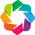

:DynamicMap   []
   :Curve   [index]   (y)

In [28]:
%run "/home/mdphuc/chipwhisperer/jupyter/Helper_Scripts/plot.ipynb"
plot = real_time_plot(plot_len=5000)

In [29]:
def text_out_to_hex_string(input_arr):
    hex_str = ""
    for i in range(len(input_arr)):
        if len(str(hex(input_arr[i]))[2:]) == 1:
            hex_str += "0" + str(hex(input_arr[i]))[2:]
        else:
            hex_str += str(hex(input_arr[i]))[2:]

    return hex_str

# 40bfabf406ee4d3042ca6b997a5c5816

In [30]:
from tqdm.notebook import tnrange
import numpy as np
import time
from Crypto.Cipher import AES

previous_dataset = None
N = 1  # Number of traces

if previous_dataset != None:
    dataset = np.load(previous_dataset)
    power_trace = list(dataset["power_trace"])
    plain_text = list(dataset["plain_text"])
    key = dataset["key"]
    plaint_text_hex_str = []
    for plaintext in plain_text:
        plaint_text_hex_str.append(text_out_to_hex_string(plaintext))
    print("Current dataset size: ", len(power_trace))
else:
    power_trace, plain_text, text_out = [],[], []
    plaint_text_hex_str = []

key = bytearray([0x2b, 0x7e, 0x15, 0x16, 0x28, 0xae, 0xd2, 0xa6, 0xab, 0xf7, 0x15, 0x88, 0x09, 0xcf, 0x4f, 0x3c])
text = bytearray([0x74, 0x69, 0x8c, 0x88, 0x1c, 0xe1, 0xd6, 0xe3, 0x56, 0x1d, 0xce, 0x31, 0x7f, 0xfa, 0x29, 0x4d])

# initialize cipher to verify DUT result:
#key, text = ktp.next()
cipher = AES.new(bytes(key), AES.MODE_ECB)
for i in tnrange(N, desc='Capturing traces'):
    # run aux stuff that should come before trace here

    #while text_out_to_hex_string(text) in plaint_text_hex_str:
    #    key, text = ktp.next()  # manual creation of a key, text pair can be substituted here
    
    trace = cw.capture_trace(scope, target, text, key)
    if not trace:
        print("Failed capture")
        continue
    
    if text_out_to_hex_string(trace[1]) in plaint_text_hex_str:
        break
    # assert text_out_to_hex_string(trace[1]) not in plaint_text_hex_str, "Duplicate password!"
    
    assert(list(trace.textout) == list(cipher.encrypt(bytes(text)))), "Incorrect encryption result!\nGot {}\nExp {}\n".format(trace.textout, list(text))
    power_trace.append(np.array(trace[0],dtype=np.float32))
    plain_text.append(np.array(trace[1]))
    plaint_text_hex_str.append(text_out_to_hex_string(trace[1]))

    text_out.append(trace.textout)
    
    ## send trace for visualization every 100th trace
    if i % 100 == 0:
        plot.send(trace)
    time.sleep(0.19)
        
key = np.array(key)  ## as key in all iterations are the same
power_trace = np.array(power_trace,dtype=np.float32)
plain_text = np.array(plain_text)

print(f"Length power trace = {len(power_trace)}")

Capturing traces:   0%|          | 0/1 [00:00<?, ?it/s]

Length power trace = 1


In [ ]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

output_notebook()
p = figure(plot_width=800)

xrange = range(len(power_trace[0]))
p.line(xrange, power_trace[0], line_color="red")
show(p)

In [31]:
import os
print(f'Key: {key}')
print(f'Text: {text}')
# used to save the data
output_path='/home/mdphuc/UCDASEC/SCA/TraceCollection/FPGA_03_21/'
os.makedirs(output_path, exist_ok=True)
outpath = os.path.join(output_path, 'CW305_ProjectVault_v1_1.npz')
print(len(power_trace))
np.savez(outpath, power_trace=power_trace, plain_text=plain_text,key=key)


Key: [ 43 126  21  22  40 174 210 166 171 247  21 136   9 207  79  60]
Text: bytearray(b'ti\x8c\x88\x1c\xe1\xd6\xe3V\x1d\xce1\x7f\xfa)M')
1


In [14]:
# project.save()
scope.dis()
target.dis()

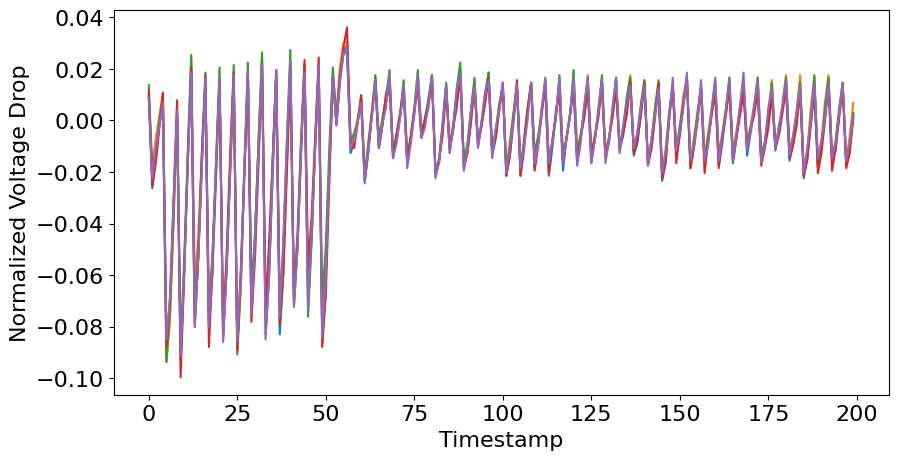

In [79]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(10,5))
plt.clf()
plt.xlabel("Timestamp")
plt.ylabel("Normalized Voltage Drop")
plt.plot(power_trace[-5])
plt.plot(power_trace[-4])
plt.plot(power_trace[-3])
plt.plot(power_trace[-2])
plt.plot(power_trace[-1])
# plt.savefig("CW305_SMAesH_same_pt_k_5it.jpg")